# pandas-arangodb example

Download, store, inspect, and filter a deps.dev dependency graph.  

A deps.dev dependency graph is a graph representation of a package and the packages it depends on. For this path:
```
PYPI / pandas / 2.2.3 / dependencies
```
deps.dev asks roughly "What dependencies make up pandas 2.2.3's dependency tree?".

This example uses ArangoDB and pandas-arangodb to ingest and query a real-world Python package dependency graph. It assumes these defaults:
```
URL:      http://127.0.0.1:8529
Username: root
Password: passwd
Database: pandas_arangodb_demo
```


In [1]:
%matplotlib widget

In [2]:
import hashlib
import json
import os
from pathlib import Path
from typing import Any
from urllib.error import HTTPError, URLError
from urllib.request import Request, urlopen
import matplotlib.pyplot as plt

import pandas as pd
from arango import ArangoClient
from arango.database import StandardDatabase

from pandas_arangodb import WriteResult, read_collection, write_collection

In [3]:
DEPS_DEV_URL = (
    "https://api.deps.dev/v3/systems/PYPI/packages/pandas/"
    "versions/2.2.3:dependencies"
)
GRAPH_NAME = "deps_demo_graph"
VERTEX_COLLECTION = "deps_demo_packages"
EDGE_COLLECTION = "deps_demo_dependencies"
RESULT_COLLECTION = "deps_demo_direct_dependencies"
VERTEX_COLUMNS = [
    "_key",
    "package",
    "version",
    "relation",
    "bundled",
    "errors",
]
EDGE_COLUMNS = ["_key", "_from", "_to", "requirement"]
CHART_PATH = "pandas_dependency_relations.png"

JsonObject = dict[str, Any]

## Download and convert the deps.dev response
### Download and decode a deps.dev dependency graph

In [4]:
def download_dependency_graph(url: str = DEPS_DEV_URL) -> JsonObject:
    request = Request(url)
    try:
        with urlopen(request, timeout=30) as response:
            body = response.read()
    except HTTPError as error:
        raise RuntimeError(
            f"deps.dev returned HTTP {error.code} for {url}"
        ) from error
    except (URLError, TimeoutError) as error:
        raise RuntimeError(f"could not download {url}: {error}") from error

    try:
        data = json.loads(body)
    except (UnicodeDecodeError, json.JSONDecodeError) as error:
        raise RuntimeError("deps.dev returned invalid JSON") from error
    if not isinstance(data, dict):
        raise ValueError("deps.dev response must be a JSON object")
    return data

In [5]:
response = download_dependency_graph()

### Validate a deps.dev response and convert its nodes and edges

In [6]:
def response_to_frames(response: JsonObject) -> tuple[pd.DataFrame, pd.DataFrame]:
    nodes = response["nodes"]
    edges = response["edges"]

    vertices: list[JsonObject] = []
    for position, node in enumerate(nodes):
        version_key = node["versionKey"]
        vertices.append(
            {
                "_key": f"node-{position}",
                "package": version_key["name"],
                "version": version_key["version"],
                "relation": node["relation"],
                "bundled": node["bundled"],
                "errors": node["errors"],
            }
        )

    dependencies: list[JsonObject] = []
    for position, edge in enumerate(edges):
        dependencies.append(
            {
                "_key": f"edge-{position}",
                "_from": f"{VERTEX_COLLECTION}/node-{edge['fromNode']}",
                "_to": f"{VERTEX_COLLECTION}/node-{edge['toNode']}",
                "requirement": edge["requirement"],
            }
        )

    vertex_frame = pd.DataFrame.from_records(vertices, columns=VERTEX_COLUMNS)
    edge_frame = pd.DataFrame.from_records(dependencies, columns=EDGE_COLUMNS)
    return vertex_frame, edge_frame

In [7]:
vertices, edges = response_to_frames(response)
print(f"Downloaded {len(vertices)} packages and {len(edges)} dependencies.")

Downloaded 6 packages and 5 dependencies.


In [8]:
vertices

,_key,package,version,relation,bundled,errors
0,node-0,pandas,2.2.3,SELF,False,[]
1,node-1,numpy,2.5.3,DIRECT,False,[]
2,node-2,python-dateutil,2.9.0.post0,DIRECT,False,[]
3,node-3,pytz,2026.3.0.post1,DIRECT,False,[]
4,node-4,six,1.17.0,INDIRECT,False,[]
5,node-5,tzdata,2026.3.0,DIRECT,False,[]


In [9]:
edges

,_key,_from,_to,requirement
0,edge-0,deps_demo_packages/node-0,deps_demo_packages/node-1,>=1.26.0
1,edge-1,deps_demo_packages/node-0,deps_demo_packages/node-2,>=2.8.2
2,edge-2,deps_demo_packages/node-0,deps_demo_packages/node-3,>=2020.1
3,edge-3,deps_demo_packages/node-0,deps_demo_packages/node-5,>=2022.7
4,edge-4,deps_demo_packages/node-2,deps_demo_packages/node-4,>=1.5


## Connect to ArangoDB and create the demo graph

### Connect to the configured server and create the demo database

In [10]:
def connect_database() -> tuple[ArangoClient, StandardDatabase]:
    url = "http://127.0.0.1:8529"
    username = "root"
    password = "passwd"
    database_name = "pandas_arangodb_demo"

    client = ArangoClient(hosts=url)
    system_database = client.db(
        "_system",
        username=username,
        password=password,
        verify=True,
    )
    if not system_database.has_database(database_name):
        system_database.create_database(database_name)

    database = client.db(
        database_name,
        username=username,
        password=password,
        verify=True,
    )
    return client, database

In [11]:
client, database = connect_database()

### Create the named graph and result collection when absent

In [12]:
def prepare_collections(database: StandardDatabase) -> None:
    if not database.has_graph(GRAPH_NAME):
        database.create_graph(
            GRAPH_NAME,
            edge_definitions=[
                {
                    "edge_collection": EDGE_COLLECTION,
                    "from_vertex_collections": [VERTEX_COLLECTION],
                    "to_vertex_collections": [VERTEX_COLLECTION],
                }
            ],
        )
    if not database.has_collection(RESULT_COLLECTION):
        database.create_collection(RESULT_COLLECTION)

In [13]:
prepare_collections(database)

### Remove data left by an earlier run from the dedicated demo collections

In [14]:
def clear_demo_collections(database: StandardDatabase) -> None:
    for collection_name in (
        EDGE_COLLECTION,
        VERTEX_COLLECTION,
        RESULT_COLLECTION,
    ):
        database.collection(collection_name).truncate()

In [15]:
clear_demo_collections(database)

## Store and read the graph

### Upsert both graph DataFrames into their ArangoDB collections

In [16]:
def store_graph(
    database: StandardDatabase,
    vertices: pd.DataFrame,
    edges: pd.DataFrame,
) -> None:
    vertex_result = write_collection(
        vertices,
        database,
        VERTEX_COLLECTION,
        mode="upsert",
    )
    edge_result = write_collection(
        edges,
        database,
        EDGE_COLLECTION,
        mode="upsert",
    )
    
    if vertex_result.errors:
        raise RuntimeError(f"failed to store {vertex_result.error_count} packages")
    if edge_result.errors:
        raise RuntimeError(f"failed to store {edge_result.error_count} dependencies")

In [17]:
store_graph(database, vertices, edges)

### Read the stored graph back through pandas-arangodb

In [18]:
def load_graph(database: StandardDatabase) -> tuple[pd.DataFrame, pd.DataFrame]:
    packages = read_collection(database, VERTEX_COLLECTION)
    dependencies = read_collection(database, EDGE_COLLECTION)
    return packages, dependencies

In [19]:
packages, dependencies = load_graph(database)
print("\nPackages read back from ArangoDB:")
print(
    packages[["package", "version", "relation"]]
    .sort_values(["relation", "package"])
    .to_string(index=False)
)


Packages read back from ArangoDB:
        package        version relation
          numpy          2.5.3   DIRECT
python-dateutil    2.9.0.post0   DIRECT
           pytz 2026.3.0.post1   DIRECT
         tzdata       2026.3.0   DIRECT
            six         1.17.0 INDIRECT
         pandas          2.2.3     SELF


In [20]:
packages

,_key,_id,_rev,package,version,relation,bundled,errors
0,node-0,deps_demo_packages/node-0,_mGATKuq---,pandas,2.2.3,SELF,False,[]
1,node-1,deps_demo_packages/node-1,_mGATKuq--_,numpy,2.5.3,DIRECT,False,[]
2,node-2,deps_demo_packages/node-2,_mGATKuu---,python-dateutil,2.9.0.post0,DIRECT,False,[]
3,node-3,deps_demo_packages/node-3,_mGATKuu--_,pytz,2026.3.0.post1,DIRECT,False,[]
4,node-4,deps_demo_packages/node-4,_mGATKuu--A,six,1.17.0,INDIRECT,False,[]
5,node-5,deps_demo_packages/node-5,_mGATKuu--B,tzdata,2026.3.0,DIRECT,False,[]


In [21]:
dependencies

,_key,_id,_from,_to,_rev,requirement
0,edge-0,deps_demo_dependencies/edge-0,deps_demo_packages/node-0,deps_demo_packages/node-1,_mGATKvC---,>=1.26.0
1,edge-1,deps_demo_dependencies/edge-1,deps_demo_packages/node-0,deps_demo_packages/node-2,_mGATKvC--_,>=2.8.2
2,edge-2,deps_demo_dependencies/edge-2,deps_demo_packages/node-0,deps_demo_packages/node-3,_mGATKvC--A,>=2020.1
3,edge-3,deps_demo_dependencies/edge-3,deps_demo_packages/node-0,deps_demo_packages/node-5,_mGATKvC--B,>=2022.7
4,edge-4,deps_demo_dependencies/edge-4,deps_demo_packages/node-2,deps_demo_packages/node-4,_mGATKvC--C,>=1.5


## Analyze and plot with pandas

### Replace edge handles with readable source and target package names

In [22]:
def readable_dependencies(
    packages: pd.DataFrame, dependencies: pd.DataFrame
) -> pd.DataFrame:
    sources = packages[["_id", "package", "version"]].rename(
        columns={
            "_id": "source_id",
            "package": "source",
            "version": "source_version",
        }
    )
    targets = packages[["_id", "package", "version"]].rename(
        columns={
            "_id": "target_id",
            "package": "target",
            "version": "target_version",
        }
    )
    readable = dependencies.merge(
        sources,
        left_on="_from",
        right_on="source_id",
        how="left",
        validate="many_to_one",
    ).merge(
        targets,
        left_on="_to",
        right_on="target_id",
        how="left",
        validate="many_to_one",
    )
    return readable[
        ["source", "source_version", "target", "target_version", "requirement"]
    ]

In [23]:
readable_edges = readable_dependencies(packages, dependencies)

In [24]:
readable_edges

,source,source_version,target,target_version,requirement
0,pandas,2.2.3,numpy,2.5.3,>=1.26.0
1,pandas,2.2.3,python-dateutil,2.9.0.post0,>=2.8.2
2,pandas,2.2.3,pytz,2026.3.0.post1,>=2020.1
3,pandas,2.2.3,tzdata,2026.3.0,>=2022.7
4,python-dateutil,2.9.0.post0,six,1.17.0,>=1.5


### Count packages in each deps.dev relationship category

In [25]:
def relation_counts(packages: pd.DataFrame) -> pd.DataFrame:
    relation_order = ["SELF", "DIRECT", "INDIRECT"]
    counts = packages["relation"].value_counts().reindex(relation_order, fill_value=0)
    return counts.rename_axis("relation").to_frame("packages")

In [26]:
counts = relation_counts(packages)

In [27]:
counts

,packages
relation,
SELF,1
DIRECT,4
INDIRECT,1


### Save the relationship counts as a bar chart

In [28]:
def save_relation_chart(counts: pd.DataFrame):
    axis = counts.plot.bar(
      legend=False,
      color="#4c78a8",
      title="pandas 2.2.3 dependency relations",
    )
    axis.set_ylabel("Package count")
    return axis

<Axes: title={'center': 'pandas 2.2.3 dependency relations'}, xlabel='relation', ylabel='Package count'>

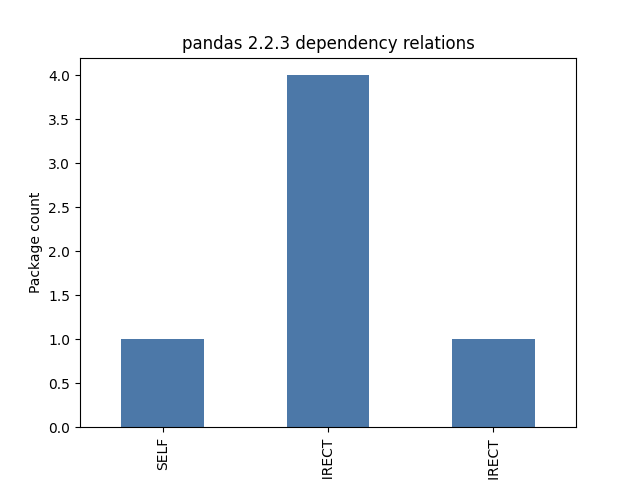

In [29]:
save_relation_chart(counts)

## Plot the dependency graph

In [30]:
def save_dependency_graph(
    packages: pd.DataFrame,
    dependencies: pd.DataFrame,
):
    nodes = packages[["_id", "package", "version", "relation"]].copy()
    relation_positions = {"SELF": 0, "DIRECT": 1, "INDIRECT": 2}
    relation_colors = {
        "SELF": "#4c78a8",
        "DIRECT": "#f58518",
        "INDIRECT": "#54a24b",
    }
    nodes["x"] = nodes["relation"].map(relation_positions)
    group_sizes = nodes.groupby("relation")["relation"].transform("size")
    nodes["y"] = (
        nodes.groupby("relation").cumcount() - (group_sizes - 1) / 2
    )

    positions = nodes.set_index("_id")[["x", "y"]]
    plotted_edges = dependencies.join(
        positions.rename(columns={"x": "source_x", "y": "source_y"}),
        on="_from",
    ).join(
        positions.rename(columns={"x": "target_x", "y": "target_y"}),
        on="_to",
    )

    figure, axis = plt.subplots()
    for _, edge in plotted_edges.iterrows():
        axis.annotate(
            "",
            xy=(edge["target_x"], edge["target_y"]),
            xytext=(edge["source_x"], edge["source_y"]),
            arrowprops={
                "arrowstyle": "->",
                "color": "#888888",
                "linewidth": 1.5,
                "shrinkA": 32,
                "shrinkB": 32,
            },
        )

    nodes.plot.scatter(
        x="x",
        y="y",
        ax=axis,
        color=nodes["relation"].map(relation_colors).tolist(),
        s=4_200,
        zorder=2,
    )
    for _, node in nodes.iterrows():
        axis.text(
            node["x"],
            node["y"],
            f"{node['package']}\n{node['version']}",
            ha="center",
            va="center",
            color="white",
            fontsize=8,
            zorder=3,
        )

    axis.set_title("pandas 2.2.3 dependency graph")
    axis.set_xticks(list(relation_positions.values()), relation_positions)
    axis.set_xlabel("")
    axis.set_ylabel("")
    axis.set_yticks([])
    axis.grid(False)
    for spine in axis.spines.values():
        spine.set_visible(False)
    axis.autoscale(enable=True, axis="both")
    axis.margins(x=0.15, y=0.20)
    
    return axis

<Axes: title={'center': 'pandas 2.2.3 dependency graph'}>

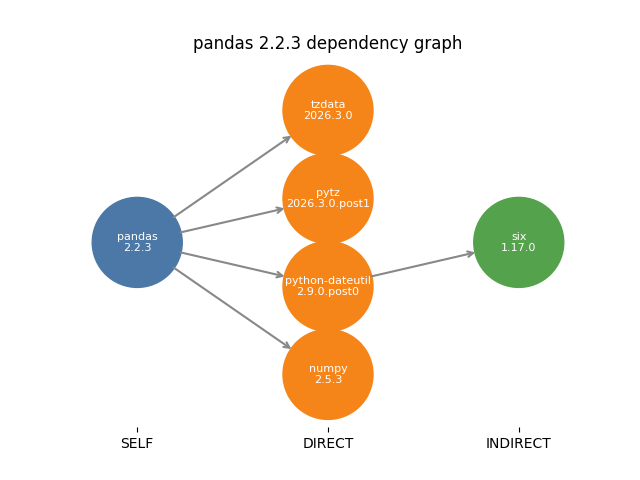

In [31]:
save_dependency_graph(packages, dependencies)

## Write the computed result

### Keep direct dependencies, store them, and read them back

In [32]:
def store_direct_dependencies(
    database: StandardDatabase,
    packages: pd.DataFrame,
) -> pd.DataFrame:
    direct_dependencies = packages.loc[
        packages["relation"].eq("DIRECT"), VERTEX_COLUMNS
    ].copy()
    result = write_collection(
        direct_dependencies,
        database,
        RESULT_COLLECTION,
        mode="upsert",
    )
    
    if result.errors:
        raise RuntimeError(f"failed to store {result.error_count} direct dependencies")
    return read_collection(database, RESULT_COLLECTION)

In [33]:
stored_direct = store_direct_dependencies(database, packages)

In [34]:
stored_direct

,_key,_id,_rev,package,version,relation,bundled,errors
0,node-1,deps_demo_direct_dependencies/node-1,_mGATS3a---,numpy,2.5.3,DIRECT,False,[]
1,node-2,deps_demo_direct_dependencies/node-2,_mGATS3a--_,python-dateutil,2.9.0.post0,DIRECT,False,[]
2,node-3,deps_demo_direct_dependencies/node-3,_mGATS3a--A,pytz,2026.3.0.post1,DIRECT,False,[]
3,node-5,deps_demo_direct_dependencies/node-5,_mGATS3a--B,tzdata,2026.3.0,DIRECT,False,[]


## Close the database client

In [35]:
client.close()